In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import transformers, datasets, accelerate, peft, tokenizers
import google.protobuf

print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("accelerate:", accelerate.__version__)
print("peft:", peft.__version__)
print("tokenizers:", tokenizers.__version__)
print("protobuf:", google.protobuf.__version__)

transformers: 4.41.2
datasets: 2.19.0
accelerate: 0.30.1
peft: 0.11.1
tokenizers: 0.19.1
protobuf: 5.29.6


In [ ]:
!pip -q install scikit-learn

In [ ]:
!pip -q install "fsspec==2024.5.0"
!pip check


ipython 7.34.0 requires jedi, which is not installed.
google-colab 1.0.0 has requirement google-auth==2.47.0, but you have google-auth 2.48.0.
google-colab 1.0.0 has requirement pandas==2.2.2, but you have pandas 3.0.1.
google-colab 1.0.0 has requirement requests==2.32.4, but you have requests 2.32.5.
pyopenssl 24.2.1 has requirement cryptography<44,>=41.0.5, but you have cryptography 46.0.5.
dask-cudf-cu12 26.2.1 has requirement pandas<2.4.0,>=2.0, but you have pandas 3.0.1.
gradio 5.50.0 has requirement pandas<3.0,>=1.0, but you have pandas 3.0.1.
grpcio-status 1.71.2 has requirement protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.5.
bqplot 0.12.45 has requirement pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1.
pydrive2 1.21.3 has requirement cryptography<44, but you have cryptography 46.0.5.
bigframes 2.36.0 has requirement rich<14,>=12.4.4, but you have rich 14.3.3.
cudf-cu12 26.2.1 has requirement pandas<2.4.0,>=2.0, but you have pandas 3.0.1.
moviepy 1.0.3 has requirement d

In [ ]:
# Clean reinstall of the exact HF stack
!pip -q uninstall -y transformers datasets accelerate peft tokenizers safetensors

!pip -q install --no-cache-dir \
  "transformers==4.41.2" \
  "datasets==2.19.0" \
  "accelerate==0.30.1" \
  "peft==0.11.1" \
  "tokenizers>=0.19.1,<0.20" \
  "safetensors>=0.4.3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 122.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 411.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 396.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 350.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 255.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 409.4 MB/s eta 0:00:00


In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import numpy, datasets, pyarrow, fsspec, gcsfs, transformers, peft, sacremoses
print("numpy", numpy.__version__)
print("datasets", datasets.__version__)
print("pyarrow", pyarrow.__version__)
print("fsspec", fsspec.__version__)
print("gcsfs", gcsfs.__version__)
print("transformers", transformers.__version__)
print("peft", peft.__version__)
print("sacremoses OK")


numpy 2.0.2
datasets 2.20.0
pyarrow 18.1.0
fsspec 2024.5.0
gcsfs 2024.5.0
transformers 5.1.0
peft 0.18.1
sacremoses OK


In [ ]:
!pip -q check


In [ ]:
!pip -q install -U "transformers==5.1.0" "accelerate>=1.0.0" "peft>=0.12.0"
!pip -q install -U "datasets==2.20.0" "pyarrow==18.1.0" "sacremoses"


In [ ]:
!pip -q install --upgrade pip
!pip -q install "transformers==4.41.2" "datasets==2.19.0" "accelerate==0.30.1" "peft==0.11.1" "safetensors>=0.4.3"

In [ ]:
# =========================
# CELL 1: Libraries + Drive + Paths
# =========================

import os, torch, pandas as pd
import torch.nn as nn
from collections import Counter
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    default_data_collator,
)
from peft import LoraConfig, get_peft_model
from google.colab import drive

drive.mount("/content/drive")

TRAIN_PATH = "/content/drive/MyDrive/Thesis/FineTunning/oral_cancer_train.csv"
TEST_PATH  = "/content/drive/MyDrive/Thesis/FineTunning/oral_cancer_test.csv"

OUT_DIR     = "/content/drive/MyDrive/Thesis/FineTunning/biogpt_lora_out_lbl"
ADAPTER_DIR = "/content/drive/MyDrive/Thesis/FineTunning/biogpt_lora_adapter_lbl"

MODEL_ID = "microsoft/biogpt"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [ ]:
# =========================
# CELL 2: Fine-tune BioGPT LoRA (LABELS: Radiotherapy / No radiation)
# =========================

train_df = pd.read_csv(TRAIN_PATH)
train_df.columns = train_df.columns.str.strip()
print("Train shape:", train_df.shape)

# --- Normalize labels to EXACT strings (important) ---
def normalize_label(x):
    s = str(x).strip().lower()
    if s == "radiotherapy":
        return "Radiotherapy"
    if s == "no radiation":
        return "No radiation"
    return "No radiation"

# --- Prompt (ONLY asks for those two labels) ---
def make_prompt_from_row(row):
    return f"""Decide radiotherapy for this oral cancer case.

Age: {row["Age"]}
Sex: {row["Sex"]}
MaritalStatus: {row["Marital status at diagnosis"]}
PrimarySite: {row["Primary Site - labeled"]}
Grade: {row["Grade"]}
TNM: {row["T stage"]} {row["N stage"]} {row["M stage"]}

Answer with exactly one of:
Radiotherapy
No radiation

Answer:
""".strip()

def make_target_from_row(row):
    return normalize_label(row["Radiotherapy"])

rows = [{"prompt": make_prompt_from_row(train_df.iloc[i]),
         "target": make_target_from_row(train_df.iloc[i])}
        for i in range(len(train_df))]

dataset = Dataset.from_list(rows)
print(dataset)

# ---------- Tokenizer ----------
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ---------- Base model ----------
base_model = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(device)
base_model.config.use_cache = False

# ---------- LoRA target modules ----------
leaf_names = []
for name, module in base_model.named_modules():
    if isinstance(module, nn.Linear):
        leaf_names.append(name.split(".")[-1])
unique_leaf = sorted(set(leaf_names))

preferred = ["q_proj","k_proj","v_proj","out_proj","fc1","fc2"]
target_modules = [x for x in preferred if x in set(unique_leaf)]
if not target_modules:
    cnt = Counter(leaf_names)
    target_modules = [x for x,_ in cnt.most_common(2)]
print("Using LoRA targets:", target_modules)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=target_modules
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# ---------- Tokenize + mask ----------
MAX_LEN = 256

def tokenize_and_mask(ex):
    prompt = ex["prompt"]
    target = ex["target"]
    full = prompt + "\n" + target

    enc = tokenizer(
        full,
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
        return_attention_mask=True
    )

    prompt_enc = tokenizer(
        prompt,
        truncation=True,
        max_length=MAX_LEN,
        add_special_tokens=True
    )
    prompt_len = min(len(prompt_enc["input_ids"]), MAX_LEN)

    labels = enc["input_ids"].copy()
    labels[:prompt_len] = [-100] * prompt_len
    labels = [(-100 if enc["attention_mask"][i] == 0 else labels[i]) for i in range(MAX_LEN)]
    enc["labels"] = labels
    return enc

tokenized = dataset.map(tokenize_and_mask, remove_columns=dataset.column_names)

# ---------- Train ----------
args = TrainingArguments(
    output_dir=OUT_DIR,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=1,     # 2 epochs helps learn label words better
    learning_rate=5e-5,     # slightly safer than 1e-4
    fp16=(device=="cuda"),
    logging_steps=25,
    save_steps=200,
    save_total_limit=2,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized,
    data_collator=default_data_collator,
)

trainer.train()

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print("Adapter saved:", ADAPTER_DIR)

Train shape: (7551, 13)
Dataset({
    features: ['prompt', 'target'],
    num_rows: 7551
})


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/595 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/7551 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Step,Training Loss
25,0.718200
50,0.442400
75,0.425000
100,0.394200
125,0.379500
150,0.369200
175,0.345200
200,0.380600
225,0.342800
250,0.363400


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Adapter saved: /content/drive/MyDrive/Thesis/FineTunning/biogpt_lora_adapter_lbl


In [ ]:
# =========================
# BIOGPT - CELL 3
# Strict 2-option output:
#   "Radiotherapy"
#   "No radiation"
# =========================

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from google.colab import drive

drive.mount("/content/drive")

# ---------- Config ----------
MODEL_ID    = "microsoft/biogpt"
ADAPTER_DIR = "/content/drive/MyDrive/Thesis/FineTunning/biogpt_lora_adapter_lbl"
TEST_PATH   = "/content/drive/MyDrive/Thesis/FineTunning/oral_cancer_test.csv"

record_from = 21
record_to   = 35
SAVE_PATH   = f"/content/drive/MyDrive/Thesis/FineTunning/BIOGPT_only2_{record_from}_{record_to}.csv"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------- Load test ----------
test_df = pd.read_csv(TEST_PATH)
test_df.columns = test_df.columns.str.strip()

subset = test_df.iloc[record_from-1:record_to].copy().reset_index(drop=True)
print("Selected rows:", len(subset))

# ---------- Load model ----------
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(device)
base.config.use_cache = False
base.eval()

model = PeftModel.from_pretrained(base, ADAPTER_DIR).to(device)
model.eval()

MAX_LEN = 256

# ---------- Prompt ----------
def make_prompt_from_row(row):
    return f"""Decide radiotherapy for this oral cancer case.

Age: {row["Age"]}
Sex: {row["Sex"]}
MaritalStatus: {row["Marital status at diagnosis"]}
PrimarySite: {row["Primary Site - labeled"]}
Grade: {row["Grade"]}
TNM: {row["T stage"]} {row["N stage"]} {row["M stage"]}

Answer with exactly one of:
Radiotherapy
No radiation

Answer:
""".strip()

# ---------- Constrained Decoding ----------
LABELS = ["Radiotherapy", "No radiation"]

def build_label_token_ids(tok, labels):
    seqs = []
    for lab in labels:
        for variant in [lab, " " + lab]:
            ids = tok(variant, add_special_tokens=False)["input_ids"]
            if ids:
                seqs.append(ids)
    # remove duplicates
    uniq, seen = [], set()
    for s in seqs:
        t = tuple(s)
        if t not in seen:
            uniq.append(s)
            seen.add(t)
    return uniq

label_token_seqs = build_label_token_ids(tokenizer, LABELS)

def make_prefix_allowed_fn(prompt_len):
    eos = tokenizer.eos_token_id

    def prefix_allowed_tokens_fn(batch_id, input_ids):
        # handle 1D or 2D tensor safely
        if input_ids.dim() == 1:
            seq = input_ids
        else:
            seq = input_ids[batch_id]

        gen = seq[prompt_len:].tolist()

        # First generated token
        if len(gen) == 0:
            return sorted({seq_ids[0] for seq_ids in label_token_seqs})

        allowed = set()
        complete = False

        for seq_ids in label_token_seqs:
            # full label matched → allow only EOS
            if gen == seq_ids:
                complete = True
                continue

            # still matching prefix
            if len(gen) < len(seq_ids) and gen == seq_ids[:len(gen)]:
                allowed.add(seq_ids[len(gen)])

        if complete and not allowed:
            return [eos]

        return list(allowed) if allowed else [eos]

    return prefix_allowed_tokens_fn

def predict_label(prompt):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN
    ).to(device)

    prompt_len = inputs["input_ids"].shape[1]
    prefix_fn = make_prefix_allowed_fn(prompt_len)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=6,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            prefix_allowed_tokens_fn=prefix_fn
        )

    gen = out[0, prompt_len:]
    return tokenizer.decode(gen, skip_special_tokens=True).strip()

# ---------- Run inference ----------
preds = []
for i in range(len(subset)):
    pred = predict_label(make_prompt_from_row(subset.iloc[i]))
    preds.append(pred)
    print(f"Record {record_from+i}: {pred}")

# ---------- Save CSV ----------
out_df = subset.copy()
out_df.insert(0, "RecordNo", list(range(record_from, record_to + 1)))
out_df = out_df.rename(columns={"Radiotherapy": "Control_Radiotherapy"})
out_df["Predicted_Radiotherapy"] = preds

out_df.to_csv(SAVE_PATH, index=False)
print("Saved:", SAVE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Selected rows: 15
Record 21: No radiation
Record 22: No radiation
Record 23: No radiation
Record 24: No radiation
Record 25: Radiotherapy
Record 26: No radiation
Record 27: Radiotherapy
Record 28: No radiation
Record 29: No radiation
Record 30: Radiotherapy
Record 31: No radiation
Record 32: No radiation
Record 33: No radiation
Record 34: No radiation
Record 35: Radiotherapy
Saved: /content/drive/MyDrive/Thesis/FineTunning/BIOGPT_only2_21_35.csv


,step,loss
0,25,0.7182
1,50,0.4424
2,75,0.4250
3,100,0.3942
4,125,0.3795
5,150,0.3692
6,175,0.3452
7,200,0.3806
8,225,0.3428
9,250,0.3634


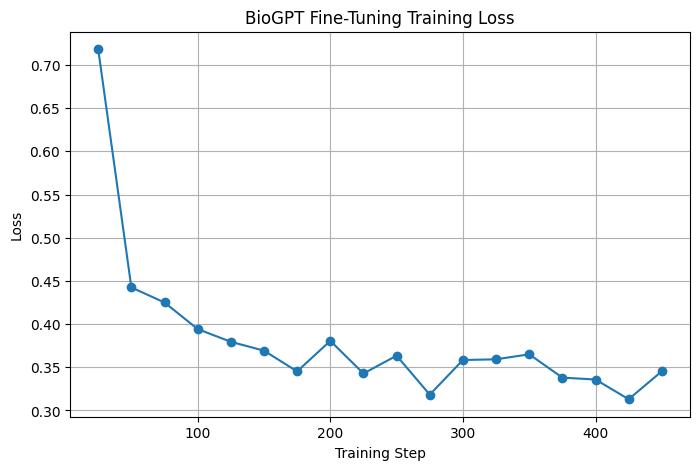

In [ ]:
# =========================
# Visualization 1: Training Loss Curve
# =========================

import pandas as pd
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
log_df = pd.DataFrame(log_history)

loss_df = log_df[log_df["loss"].notna()].copy()

if loss_df.empty:
    print("No loss values found in trainer.state.log_history")
else:
    display(loss_df[["step", "loss"]])

    plt.figure(figsize=(8, 5))
    plt.plot(loss_df["step"], loss_df["loss"], marker="o")
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.title("BioGPT Fine-Tuning Training Loss")
    plt.grid(True)
    plt.show()

Columns in out_df:
['RecordNo', 'Age', 'Sex', 'Marital status at diagnosis', 'Primary Site - labeled', 'Grade', 'T stage', 'N stage', 'M stage', 'Control_Radiotherapy', 'Surgical treatment', 'Chemotherapy', 'Survival months', 'Overall survival', 'Predicted_Radiotherapy']

True labels:
['No radiation', 'Radiotherapy', 'No radiation', 'No radiation', 'Radiotherapy', 'No radiation', 'Radiotherapy', 'No radiation', 'No radiation', 'Radiotherapy', 'Radiotherapy', 'No radiation', 'No radiation', 'No radiation', 'Radiotherapy']

Predicted labels:
['No radiation', 'No radiation', 'No radiation', 'No radiation', 'Radiotherapy', 'No radiation', 'Radiotherapy', 'No radiation', 'No radiation', 'Radiotherapy', 'No radiation', 'No radiation', 'No radiation', 'No radiation', 'Radiotherapy']


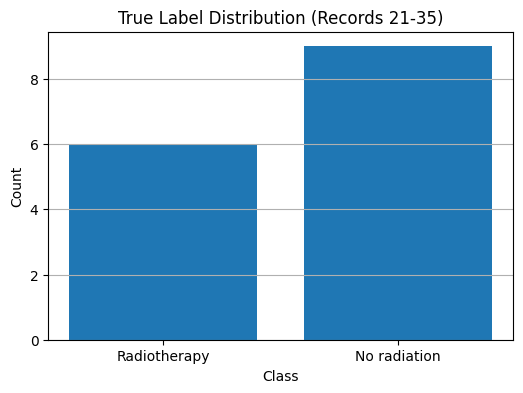

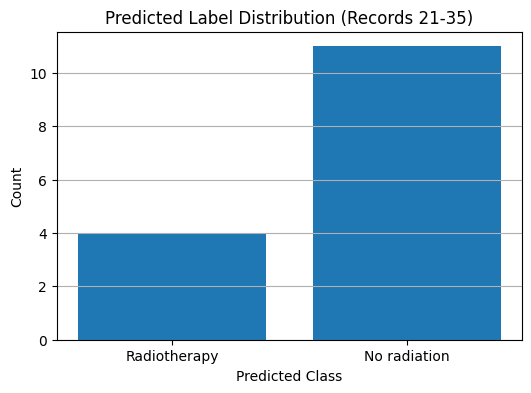

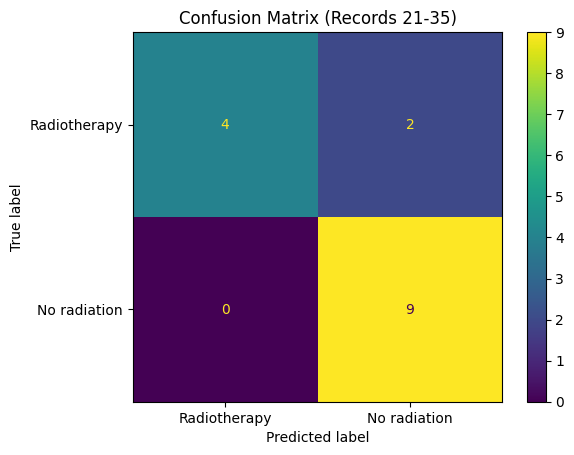


Classification Report:

              precision    recall  f1-score   support

Radiotherapy       1.00      0.67      0.80         6
No radiation       0.82      1.00      0.90         9

    accuracy                           0.87        15
   macro avg       0.91      0.83      0.85        15
weighted avg       0.89      0.87      0.86        15



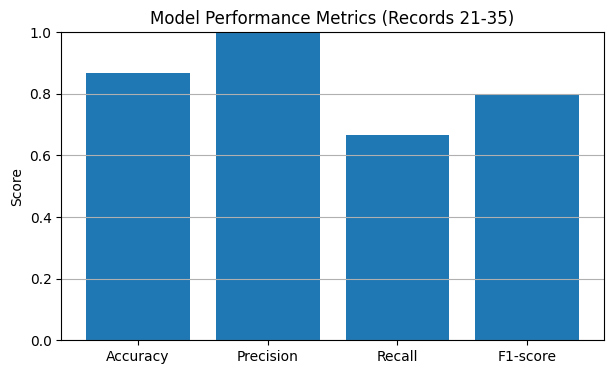

Accuracy : 0.8667
Precision: 1.0
Recall   : 0.6667
F1-score : 0.8

Prediction Details:

    RecordNo        Actual     Predicted  Correct
0         21  No radiation  No radiation     True
1         22  Radiotherapy  No radiation    False
2         23  No radiation  No radiation     True
3         24  No radiation  No radiation     True
4         25  Radiotherapy  Radiotherapy     True
5         26  No radiation  No radiation     True
6         27  Radiotherapy  Radiotherapy     True
7         28  No radiation  No radiation     True
8         29  No radiation  No radiation     True
9         30  Radiotherapy  Radiotherapy     True
10        31  Radiotherapy  No radiation    False
11        32  No radiation  No radiation     True
12        33  No radiation  No radiation     True
13        34  No radiation  No radiation     True
14        35  Radiotherapy  Radiotherapy     True


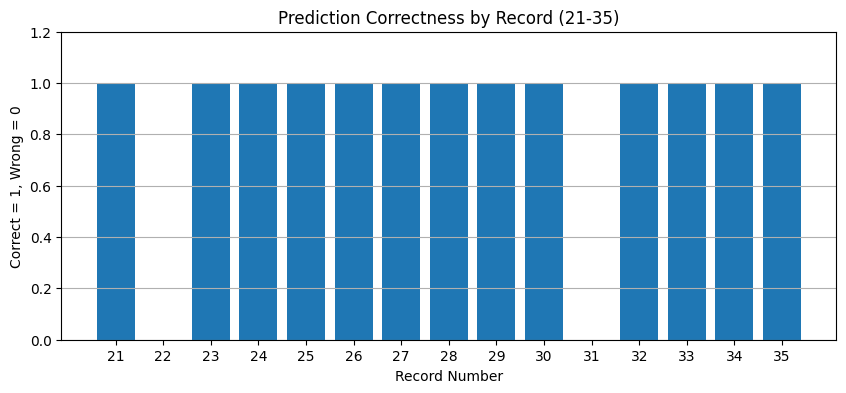

In [ ]:
# =========================
# CELL 3B: Visualizations for records 21-35
# Uses out_df created in CELL 3
# =========================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# -------------------------
# Check columns
# -------------------------
print("Columns in out_df:")
print(out_df.columns.tolist())

required_cols = ["Control_Radiotherapy", "Predicted_Radiotherapy"]
for col in required_cols:
    if col not in out_df.columns:
        raise ValueError(f"Column '{col}' not found in out_df")

# -------------------------
# Normalize labels
# -------------------------
def normalize_label(x):
    s = str(x).strip().lower()
    if s == "radiotherapy":
        return "Radiotherapy"
    elif s == "no radiation":
        return "No radiation"
    else:
        return str(x).strip()

y_true = out_df["Control_Radiotherapy"].apply(normalize_label)
y_pred = out_df["Predicted_Radiotherapy"].apply(normalize_label)

labels = ["Radiotherapy", "No radiation"]

print("\nTrue labels:")
print(y_true.tolist())

print("\nPredicted labels:")
print(y_pred.tolist())

# -------------------------
# 1. True label distribution
# -------------------------
true_counts = y_true.value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(6, 4))
plt.bar(true_counts.index, true_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("True Label Distribution (Records 21-35)")
plt.grid(axis="y")
plt.show()

# -------------------------
# 2. Predicted label distribution
# -------------------------
pred_counts = y_pred.value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(6, 4))
plt.bar(pred_counts.index, pred_counts.values)
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.title("Predicted Label Distribution (Records 21-35)")
plt.grid(axis="y")
plt.show()

# -------------------------
# 3. Confusion Matrix
# -------------------------
cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Records 21-35)")
plt.show()

# -------------------------
# 4. Metrics
# -------------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label="Radiotherapy", zero_division=0)
recall = recall_score(y_true, y_pred, pos_label="Radiotherapy", zero_division=0)
f1 = f1_score(y_true, y_pred, pos_label="Radiotherapy", zero_division=0)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

plt.figure(figsize=(7, 4))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance Metrics (Records 21-35)")
plt.grid(axis="y")
plt.show()

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

# -------------------------
# 5. Row-wise correctness view
# -------------------------
result_df = pd.DataFrame({
    "RecordNo": out_df["RecordNo"],
    "Actual": y_true,
    "Predicted": y_pred
})

result_df["Correct"] = result_df["Actual"] == result_df["Predicted"]
print("\nPrediction Details:\n")
print(result_df)

plt.figure(figsize=(10, 4))
plt.bar(
    result_df["RecordNo"].astype(str),
    result_df["Correct"].astype(int)
)
plt.xlabel("Record Number")
plt.ylabel("Correct = 1, Wrong = 0")
plt.title("Prediction Correctness by Record (21-35)")
plt.ylim(0, 1.2)
plt.grid(axis="y")
plt.show()